# LeJEPA Pretraining Playground

Train from scratch with the 4 experiment methods. Saves checkpoints to
`runs/lejepa_v1/` — the sweep script (`run_sweep.py`) skips runs whose
`final.pt` already exists, so notebook results carry over.

In [1]:
import sys, os
REPO_ROOT = os.path.abspath('..')
DATA_DIR = os.path.join(REPO_ROOT, 'data')
PRETRAIN = os.path.join(REPO_ROOT, 'experiments', 'pretrain')
SAVE_DIR = os.path.join(REPO_ROOT, 'runs', 'lejepa_v1')

sys.path.insert(0, PRETRAIN)
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))
sys.path.insert(0, REPO_ROOT)

import torch, time
import matplotlib.pyplot as plt
from pathlib import Path

from configs import Config, DATASET_INFO
from data import get_dataloaders, InMemoryGPUDataset
from models import LeJEPAEncoder, LinearProbe
from losses import build_regularizer, build_sigreg, build_emb_regularizer, build_sigreg_emb
from scheduler import make_scheduler
from trainer import setup_seed
from checkpoint import save_checkpoint
from train_loops import (
    FIFOBuffer,
    train_epoch_standard_inmem,
    train_epoch_standard_loader,
    train_epoch_pooled_inmem,
    train_epoch_pooled_loader,
    make_nograd_loader,
    evaluate,
    eval_distribution,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Data dir: {DATA_DIR}')
print(f'Save dir: {SAVE_DIR}')
print(f'Available datasets: {list(DATASET_INFO.keys())}')

Device: cuda
Data dir: /home/kevin-cheung/Desktop/StackedLeJepa/data
Save dir: /home/kevin-cheung/Desktop/StackedLeJepa/runs/lejepa_v1
Available datasets: ['cifar100', 'cifar10', 'food101', 'stl10', 'pets', 'aircraft', 'dtd', 'flowers102']


/home/kevin-cheung/Desktop/StackedLeJepa/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training function (with checkpoint saving)

In [2]:
def run_tag(cfg):
    """Build a run directory name from config."""
    method = cfg.regularizer
    if cfg.accumulate:
        method += '_pooled'
    if cfg.fifo_size > 0:
        method += f'_fifo{cfg.fifo_size}'
    return f'{cfg.dataset}_{cfg.encoder_scale}_{method}_bs{cfg.batch_size}_seed{cfg.seed}'


def run_training(cfg, save_dir=SAVE_DIR):
    """Train from scratch, save checkpoints, return history dict.

    Skips if save_dir/tag/final.pt already exists (same convention as
    trainer.py / run_sweep.py).
    """
    tag = run_tag(cfg)
    run_dir = Path(save_dir) / tag
    final_path = run_dir / 'final.pt'

    if final_path.exists():
        print(f'SKIP (already done): {final_path}')
        return None

    run_dir.mkdir(parents=True, exist_ok=True)
    setup_seed(cfg.seed)
    train_source, val_source, gpu_aug = get_dataloaders(cfg, device)
    in_memory = isinstance(train_source, InMemoryGPUDataset)

    encoder = LeJEPAEncoder(cfg).to(device)
    probe_dim = encoder.hidden_dim if cfg.probe_on_emb else cfg.proj_dim
    probe = LinearProbe(probe_dim, cfg.num_classes).to(device)
    if cfg.use_compile:
        encoder = torch.compile(encoder)
    print(f'{tag}  |  params={sum(p.numel() for p in encoder.parameters()):,}')

    enc_opt = torch.optim.AdamW(encoder.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    probe_opt = torch.optim.AdamW(probe.parameters(), lr=cfg.probe_lr, weight_decay=cfg.probe_wd)

    if in_memory:
        steps_per_epoch = len(train_source) // cfg.batch_size
    else:
        steps_per_epoch = len(train_source)
    warmup_steps = cfg.warmup_epochs * steps_per_epoch

    enc_sched = make_scheduler(enc_opt, warmup_steps, cfg.lr)
    probe_sched = make_scheduler(probe_opt, warmup_steps, cfg.probe_lr)

    reg_fn = None
    reg_emb_fn = None
    sigreg_mod = None
    sigreg_emb_mod = None
    nograd_loader = None
    nograd_iter_state = [None]
    fifo = FIFOBuffer(cfg.fifo_size) if cfg.fifo_size > 0 else None

    if not cfg.accumulate:
        reg_fn = build_regularizer(cfg, device)
        reg_emb_fn = build_emb_regularizer(cfg, device)
    else:
        sigreg_mod = build_sigreg(cfg, device)
        sigreg_emb_mod = build_sigreg_emb(cfg, device)
        if not in_memory and cfg.nograd_pool_size > 0:
            nograd_bs = cfg.nograd_pool_size
            nograd_loader = make_nograd_loader(
                train_source.dataset, nograd_bs, cfg.num_workers)
            nograd_iter_state = [iter(nograd_loader)]

    sample_gen = torch.Generator(device=device).manual_seed(cfg.seed) if in_memory else None
    history = {'epoch': [], 'train_loss': [], 'val_acc': [],
               'lam': [], 'mu': [], 'eps': [],
               'w1': [], 'w2': [], 'mean_norm': [], 'cov_frob_rel': [],
               'cov_diag_mean': [], 'cov_offdiag_max': [],
               'proj_eff_rank': [], 'emb_eff_rank': [],
               'emb_eff_rank_ratio': [], 'emb_dim': [],
               'emb_w1': [], 'emb_w2': [], 'emb_cov_frob_rel': []}
    global_step = 0
    best_val_acc = 0.0

    for epoch in range(cfg.epochs):
        t0 = time.time()
        if cfg.accumulate and in_memory:
            avg_loss, global_step = train_epoch_pooled_inmem(
                epoch, encoder, probe, train_source,
                gpu_aug, enc_opt, probe_opt, enc_sched, probe_sched, cfg,
                global_step, sample_gen, sigreg_mod,
                fifo=fifo, sigreg_emb_mod=sigreg_emb_mod)
        elif cfg.accumulate:
            avg_loss, global_step = train_epoch_pooled_loader(
                epoch, encoder, probe, train_source,
                gpu_aug, nograd_loader, nograd_iter_state,
                enc_opt, probe_opt, enc_sched, probe_sched, cfg,
                global_step, sigreg_mod, fifo=fifo,
                sigreg_emb_mod=sigreg_emb_mod)
        elif in_memory:
            avg_loss, global_step = train_epoch_standard_inmem(
                epoch, encoder, probe, reg_fn, train_source,
                gpu_aug, enc_opt, probe_opt, enc_sched, probe_sched,
                cfg, global_step, sample_gen, reg_emb_fn)
        else:
            avg_loss, global_step = train_epoch_standard_loader(
                epoch, encoder, probe, reg_fn, train_source,
                gpu_aug, enc_opt, probe_opt, enc_sched, probe_sched,
                cfg, global_step, reg_emb_fn)

        val_acc = evaluate(encoder, probe, val_source, cfg)
        dist = eval_distribution(encoder, val_source, cfg)
        elapsed = time.time() - t0

        history['epoch'].append(epoch)
        history['train_loss'].append(avg_loss)
        history['val_acc'].append(val_acc)
        for k in ('w1', 'w2', 'mean_norm', 'cov_frob_rel',
                  'cov_diag_mean', 'cov_offdiag_max',
                  'proj_eff_rank', 'emb_eff_rank',
                  'emb_eff_rank_ratio', 'emb_dim',
                  'emb_w1', 'emb_w2', 'emb_cov_frob_rel'):
            history[k].append(dist.get(k, float('nan')))

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if (epoch + 1) % cfg.eval_interval == 0:
            tag = 'emb' if cfg.probe_on_emb else 'proj'
            print(f'  epoch {epoch} | loss={avg_loss:.4f} val({tag})={val_acc:.4f} '
                  f'best={best_val_acc:.4f} | '
                  f'w1={dist["w1"]:.3f} emb_w1={dist.get("emb_w1", 0):.3f} | '
                  f'rank proj={dist["proj_eff_rank"]:.2f}/{cfg.proj_dim} '
                  f'emb={dist["emb_eff_rank"]:.2f}/{dist["emb_dim"]} | '
                  f'{elapsed:.1f}s')

        if (epoch + 1) % cfg.save_interval == 0:
            save_checkpoint(
                str(run_dir / f'epoch{epoch+1}.pt'), encoder, probe,
                enc_opt, probe_opt, enc_sched, probe_sched,
                epoch, global_step, cfg, best_val_acc)

    save_checkpoint(
        str(final_path), encoder, probe,
        enc_opt, probe_opt, enc_sched, probe_sched,
        cfg.epochs - 1, global_step, cfg, best_val_acc)
    print(f'Saved: {final_path}  (best val_acc={best_val_acc:.4f})')
    return history

## Train 4 methods from scratch

Each run saves to `runs/lejepa_v1/{tag}/final.pt`. If it already exists
(from a previous notebook run or from `run_sweep.py`), it is skipped.

In [6]:
# STL10 (5000 train @ 96px) is the fast iteration setup — should run
# at ~3-4s/epoch vs ~37s for CIFAR100. Switch DATASET back to 'cifar100'
DATASET = "cifar100"#'flowers102'
BS = 128
EPOCHS = 1000

# (regularizer, accumulate) — the 4 methods from EXPERIMENT_PLAN.md
METHODS = [
    ('sigreg', False),
    # ('sigreg', True),
    # ('sigreg+w1', True),
    # ('w1',     False),
    # ('w1',     True),
]

results = {}
for reg, pooled in METHODS:
    label = f'{reg}{"_pooled" if pooled else ""}'
    print(f'\n=== {label} ===')
    cfg = Config(
        dataset=DATASET, data_dir=DATA_DIR,
        encoder_scale='resnet18',
        regularizer=reg, accumulate=pooled,
        batch_size=BS, epochs=EPOCHS, num_inv_nograd_views=0, detach_inv_centroid=False,
        use_compile=True, num_workers=4,
        eval_interval=1, save_interval=25,
        log_interval=100, seed=42, nograd_pool_size=128, fifo_size=0,
        proj_dim=128, inv_on_emb=False, probe_on_emb=False,
        num_aug_views=2, lr=5e-4,
        blur_p=0.5, solarize_p=0.2,
        lambd=0.05, lambd_emb=0.0,
    )
    h = run_training(cfg)
    if h is not None:
        results[label] = h


=== sigreg ===
  [backbone] Patched resnet18 stem for low-res input (32x32)
cifar100_resnet18_sigreg_bs128_seed42  |  params=30,592,192
  epoch 0 step 100 | loss 5.0798 reg 5.2500 inv 0.2494 probe_loss 4.5812 probe_acc(proj) 0.016 lr 0.000128
  epoch 0 step 200 | loss 4.7148 reg 4.0000 inv 0.2557 probe_loss 4.2717 probe_acc(proj) 0.062 lr 0.000256
  epoch 0 step 300 | loss 4.3976 reg 4.0312 inv 0.2257 probe_loss 3.9820 probe_acc(proj) 0.125 lr 0.000385
  epoch 0 | loss=4.8694 val(proj)=0.1072 best=0.1072 | w1=0.247 emb_w1=0.644 | rank proj=42.46/128 emb=221.30/512 | 12.6s
  epoch 1 step 100 | loss 4.0284 reg 3.2969 inv 0.2187 probe_loss 3.6556 probe_acc(proj) 0.172 lr 0.000500
  epoch 1 step 200 | loss 4.1388 reg 2.9531 inv 0.2160 probe_loss 3.7861 probe_acc(proj) 0.125 lr 0.000500
  epoch 1 step 300 | loss 3.9866 reg 3.0781 inv 0.2107 probe_loss 3.6321 probe_acc(proj) 0.102 lr 0.000500
  epoch 1 | loss=4.1386 val(proj)=0.1395 best=0.1395 | w1=0.184 emb_w1=0.625 | rank proj=41.42/128 

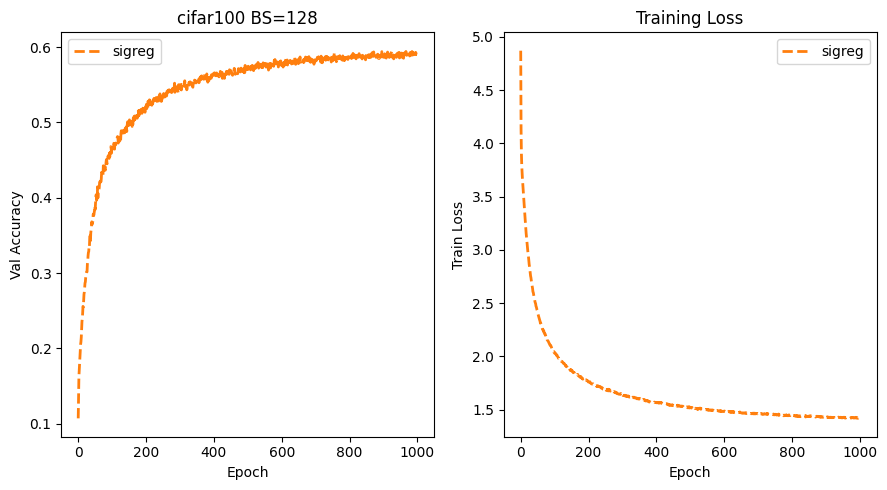

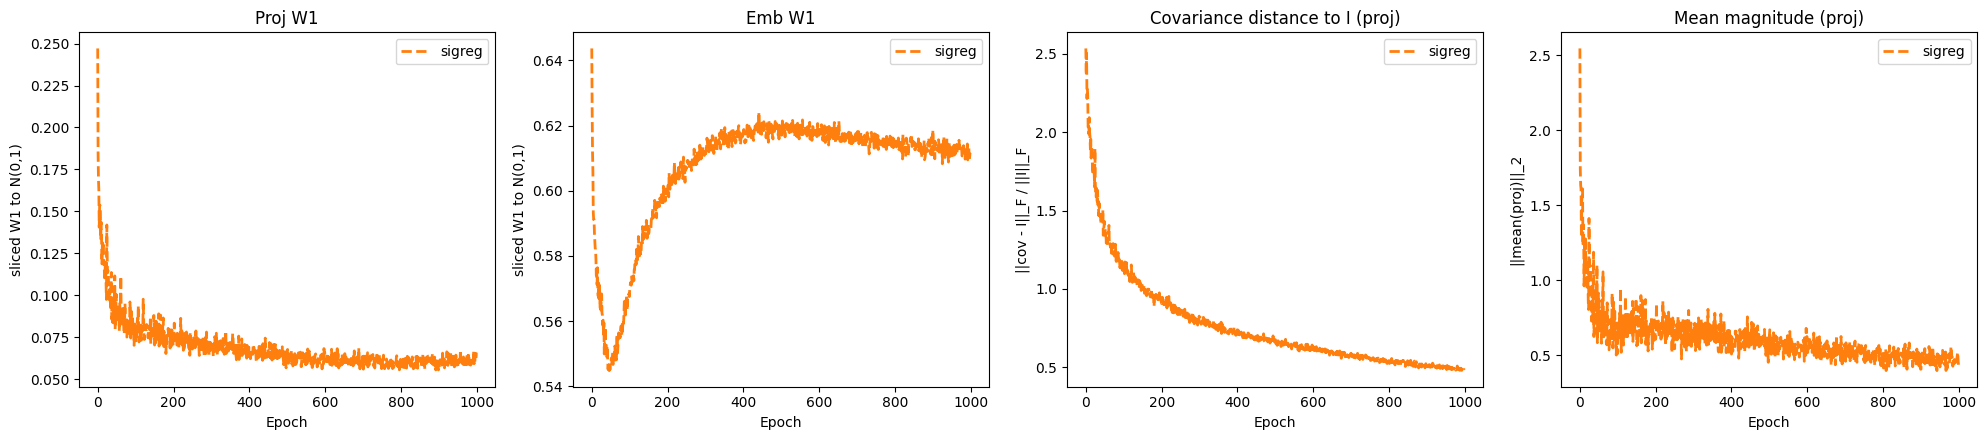

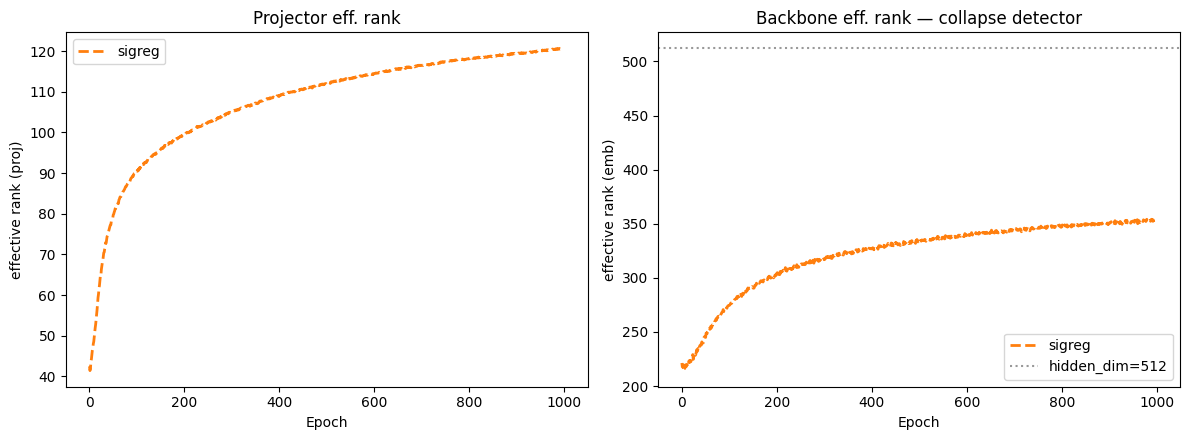

In [7]:
colors = {'sigreg': 'tab:orange', 'sigreg_pooled': 'tab:red',
          'w1': 'tab:blue', 'w1_pooled': 'tab:green'}
styles = {'sigreg': '--', 'sigreg_pooled': '-',
          'w1': '--', 'w1_pooled': '-'}

has_lag = any(len(h.get('lam', [])) > 0 for h in results.values())
ncols = 4 if has_lag else 2
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols / 2 + 2, 5))
ax1, ax2 = axes[0], axes[1]
ax_lam = axes[2] if has_lag else None
ax_eps = axes[3] if has_lag else None

for label, h in results.items():
    c = colors.get(label, 'gray')
    ls = styles.get(label, '-')
    ax1.plot(h['epoch'], h['val_acc'], label=label, color=c, linestyle=ls, linewidth=2)
    ax2.plot(h['epoch'], h['train_loss'], label=label, color=c, linestyle=ls, linewidth=2)
    if ax_lam is not None and len(h.get('lam', [])) > 0:
        ax_lam.plot(h['epoch'], h['lam'], label=label, color=c, linestyle=ls, linewidth=2)
        ax_eps.plot(h['epoch'], h['mu'], label=f'{label} μ', color=c, linestyle=':', linewidth=1.5)
        ax_eps.plot(h['epoch'], h['eps'], label=f'{label} ε', color=c, linestyle='-', linewidth=2)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Accuracy')
ax1.set_title(f'{DATASET} BS={BS}'); ax1.legend()
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Train Loss')
ax2.set_title('Training Loss'); ax2.legend()
if ax_lam is not None:
    ax_lam.set_xlabel('Epoch'); ax_lam.set_ylabel('λ (dual)')
    ax_lam.set_title('Dual variable'); ax_lam.legend()
    ax_eps.set_xlabel('Epoch'); ax_eps.set_ylabel('L_dist')
    ax_eps.set_title('μ (EMA) vs ε (target)'); ax_eps.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Distributional metrics: how close is proj output to N(0, I)?
fig2, axd = plt.subplots(1, 4, figsize=(20, 4.5))
for label, h in results.items():
    c = colors.get(label, 'gray')
    ls = styles.get(label, '-')
    axd[0].plot(h['epoch'], h['w1'], label=label, color=c, linestyle=ls, linewidth=2)
    axd[1].plot(h['epoch'], h.get('emb_w1', []), label=label, color=c, linestyle=ls, linewidth=2)
    axd[2].plot(h['epoch'], h['cov_frob_rel'], label=label, color=c, linestyle=ls, linewidth=2)
    axd[3].plot(h['epoch'], h['mean_norm'], label=label, color=c, linestyle=ls, linewidth=2)
axd[0].set_xlabel('Epoch'); axd[0].set_ylabel('sliced W1 to N(0,1)')
axd[0].set_title('Proj W1'); axd[0].legend()
axd[1].set_xlabel('Epoch'); axd[1].set_ylabel('sliced W1 to N(0,1)')
axd[1].set_title('Emb W1'); axd[1].legend()
axd[2].set_xlabel('Epoch'); axd[2].set_ylabel('||cov - I||_F / ||I||_F')
axd[2].set_title('Covariance distance to I (proj)'); axd[2].legend()
axd[3].set_xlabel('Epoch'); axd[3].set_ylabel('||mean(proj)||_2')
axd[3].set_title('Mean magnitude (proj)'); axd[3].legend()
plt.tight_layout()
plt.show()

# Rank diagnostics: detect backbone collapse when proj_dim is small.
fig3, axr = plt.subplots(1, 2, figsize=(12, 4.5))
for label, h in results.items():
    c = colors.get(label, 'gray')
    ls = styles.get(label, '-')
    axr[0].plot(h['epoch'], h['proj_eff_rank'], label=label, color=c, linestyle=ls, linewidth=2)
    axr[1].plot(h['epoch'], h['emb_eff_rank'], label=label, color=c, linestyle=ls, linewidth=2)
# Reference lines: max possible rank for proj (proj_dim) and emb (hidden_dim).
proj_max = max((max(h['proj_eff_rank']) for h in results.values()), default=0)
emb_dim_seen = next((h['emb_dim'][-1] for h in results.values() if h.get('emb_dim')), None)
if emb_dim_seen is not None:
    axr[1].axhline(emb_dim_seen, color='black', linestyle=':', alpha=0.4,
                   label=f'hidden_dim={emb_dim_seen}')
axr[0].set_xlabel('Epoch'); axr[0].set_ylabel('effective rank (proj)')
axr[0].set_title('Projector eff. rank'); axr[0].legend()
axr[1].set_xlabel('Epoch'); axr[1].set_ylabel('effective rank (emb)')
axr[1].set_title('Backbone eff. rank — collapse detector'); axr[1].legend()
plt.tight_layout()
plt.show()